<a href="https://colab.research.google.com/github/AdarkarRavaji2004/CSL701-CS01_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Ravaji P. Adarkar

Batch : CS-1


Roll Number : CS01



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree

from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("brca.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

data.head()

Dataset loaded successfully!
Dataset shape: (569, 32)


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [3]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nColumn names:")
print(data.columns.tolist())

Number of rows: 569
Number of columns: 32

Column names:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']


In [4]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64


In [5]:
print("Summary Statistics:")
print(data.describe())

Summary Statistics:
       Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  \
count  569.000000     569.000000      569.000000        569.000000   
mean   285.000000      14.127292       19.289649         91.969033   
std    164.400426       3.524049        4.301036         24.298981   
min      1.000000       6.981000        9.710000         43.790000   
25%    143.000000      11.700000       16.170000         75.170000   
50%    285.000000      13.370000       18.840000         86.240000   
75%    427.000000      15.780000       21.800000        104.100000   
max    569.000000      28.110000       39.280000        188.500000   

       x.area_mean  x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
count   569.000000         569.000000          569.000000        569.000000   
mean    654.889104           0.096360            0.104341          0.088799   
std     351.914129           0.014064            0.052813          0.079720   
min     143.500000           0.05

In [6]:
print("Class Distribution:")
print(data["y"].value_counts())

Class Distribution:
y
B    357
M    212
Name: count, dtype: int64


# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [7]:
# Remove ID column
data = data.drop("Unnamed: 0", axis=1)

# Separate features and target
X = data.drop("y", axis=1)
y = data["y"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (569, 30)
Target shape: (569,)


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Feature scaling completed.
Scaled data shape: (569, 30)


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [9]:
distance_matrix = squareform(
    pdist(X_scaled, metric="euclidean")
)

print("Distance matrix shape:", distance_matrix.shape)

Distance matrix shape: (569, 569)


In [10]:
print(distance_matrix[:5, :5])

[[0.         3.10724668 3.62314178 5.20448164 4.46708561]
 [3.10724668 0.         4.01027585 5.62302017 4.37098277]
 [3.62314178 4.01027585 0.         5.12193591 2.94839575]
 [5.20448164 5.62302017 5.12193591 0.         5.02798792]
 [4.46708561 4.37098277 2.94839575 5.02798792 0.        ]]


In [11]:
G = nx.Graph()

# Add nodes
G.add_nodes_from(range(len(X_scaled)))

# Add weighted edges
for i in range(len(X_scaled)):
    for j in range(i + 1, len(X_scaled)):
        G.add_edge(i, j, weight=distance_matrix[i, j])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 569
Number of edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [12]:
mst_matrix = minimum_spanning_tree(distance_matrix)

print("Minimum Spanning Tree calculated successfully!")

Minimum Spanning Tree calculated successfully!


In [13]:
mst_graph = nx.from_scipy_sparse_array(mst_matrix)

print("MST nodes:", mst_graph.number_of_nodes())
print("MST edges:", mst_graph.number_of_edges())

MST nodes: 569
MST edges: 568


In [14]:
mst_edges = []

for u, v, data_edge in mst_graph.edges(data=True):
    mst_edges.append((u, v, data_edge["weight"]))

mst_edges = sorted(mst_edges, key=lambda x: x[2])

print("First 10 MST edges:")

for edge in mst_edges[:10]:
    print(edge)

First 10 MST edges:
(23, 201, 1.0061149471356947)
(271, 272, 1.0276139961568989)
(132, 219, 1.097096353134243)
(363, 505, 1.100975975252204)
(29, 339, 1.120852682272412)
(152, 288, 1.1477103977680023)
(21, 57, 1.1487117257852832)
(40, 304, 1.2105916054697365)
(248, 319, 1.2162461072549684)
(74, 149, 1.2180077186880458)


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [15]:
sorted_edges = sorted(
    mst_graph.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
)

print("Largest MST edges:")

for u, v, edge_data in sorted_edges[:10]:
    print(
        "Node:", u,
        "Node:", v,
        "Weight:", edge_data["weight"]
    )

Largest MST edges:
Node: 544 Node: 553 Weight: 12.299945385815649
Node: 18 Node: 69 Weight: 10.476074912430871
Node: 48 Node: 468 Weight: 8.826434347268258
Node: 467 Node: 544 Weight: 8.26854194336771
Node: 424 Node: 429 Weight: 8.07798415946937
Node: 360 Node: 454 Weight: 7.87103948027092
Node: 18 Node: 208 Weight: 7.791092719319788
Node: 412 Node: 515 Weight: 7.089525607141025
Node: 454 Node: 515 Weight: 7.062629598697372
Node: 369 Node: 395 Weight: 6.968998137974113


In [16]:
cluster_graph = mst_graph.copy()

# K = 2, therefore remove K-1 = 1 edge
largest_edge = sorted_edges[0]

u = largest_edge[0]
v = largest_edge[1]

cluster_graph.remove_edge(u, v)

print("Largest edge removed.")
print("Node 1:", u)
print("Node 2:", v)
print("Weight:", largest_edge[2]["weight"])

Largest edge removed.
Node 1: 544
Node 2: 553
Weight: 12.299945385815649


In [17]:
components = list(nx.connected_components(cluster_graph))

print("Number of clusters:", len(components))

for i, component in enumerate(components):
    print("Cluster", i, "size:", len(component))

Number of clusters: 2
Cluster 0 size: 567
Cluster 1 size: 2


In [18]:
cluster_labels = np.zeros(len(X_scaled), dtype=int)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

print("Cluster labels assigned successfully!")

print("\nFirst 20 cluster labels:")
print(cluster_labels[:20])

Cluster labels assigned successfully!

First 20 cluster labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [19]:
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

In [20]:
true_labels = y.map({
    "B": 0,
    "M": 1
})

print(true_labels.head())

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64


In [21]:
silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.6606668813897673


In [22]:
ari = adjusted_rand_score(
    true_labels,
    cluster_labels
)

print("Adjusted Rand Index (ARI):", ari)

Adjusted Rand Index (ARI): 0.0048283446965917305


In [23]:
nmi = normalized_mutual_info_score(
    true_labels,
    cluster_labels
)

print("Normalized Mutual Information (NMI):", nmi)

Normalized Mutual Information (NMI): 0.010182219220269649


In [24]:
print("========== MST CLUSTERING RESULTS ==========")

print("Silhouette Score :", round(silhouette, 4))
print("ARI              :", round(ari, 4))
print("NMI              :", round(nmi, 4))

========== MST CLUSTERING RESULTS ==========
Silhouette Score : 0.6607
ARI              : 0.0048
NMI              : 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

In [25]:
feature_x = data["x.radius_mean"]
feature_y = data["x.texture_mean"]

print("X-axis: x.radius_mean")
print("Y-axis: x.texture_mean")

X-axis: x.radius_mean
Y-axis: x.texture_mean


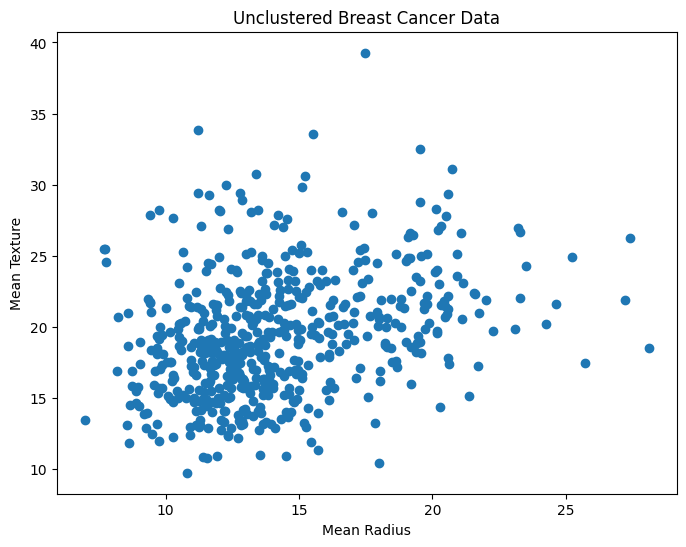

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    feature_x,
    feature_y
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Unclustered Breast Cancer Data")

plt.show()

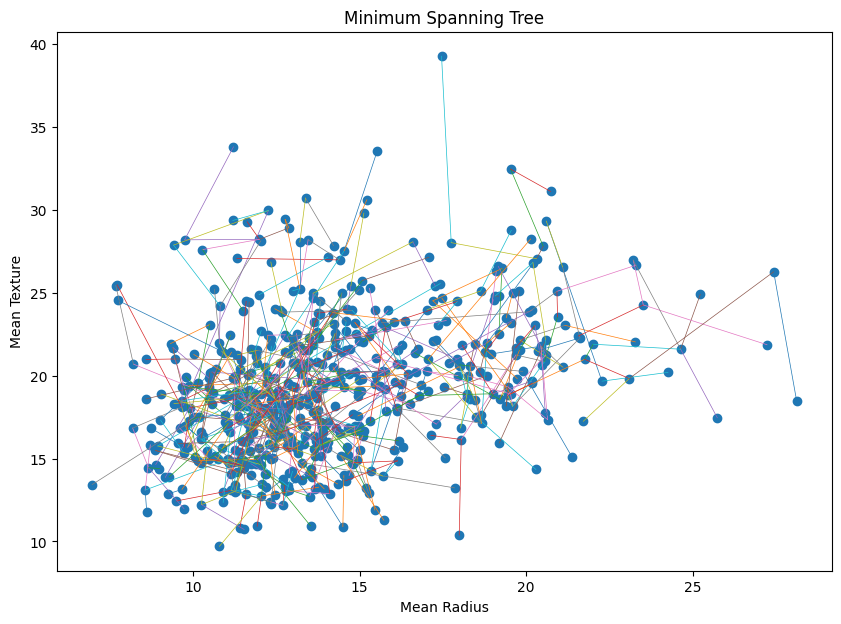

In [27]:
plt.figure(figsize=(10, 7))

# Plot data points
plt.scatter(
    feature_x,
    feature_y
)

# Plot MST edges
for u, v, edge_data in mst_graph.edges(data=True):

    plt.plot(
        [feature_x.iloc[u], feature_x.iloc[v]],
        [feature_y.iloc[u], feature_y.iloc[v]],
        linewidth=0.5
    )

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Minimum Spanning Tree")

plt.show()

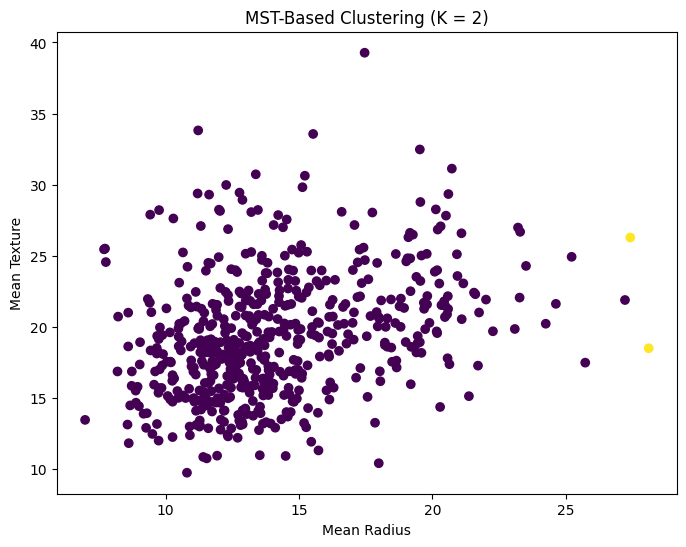

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    feature_x,
    feature_y,
    c=cluster_labels,
    cmap="viridis"
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("MST-Based Clustering (K = 2)")

plt.show()

In [29]:
print("====================================")
print("       FINAL EXPERIMENT RESULTS")
print("====================================")

print("\nDataset:")
print("Samples:", X.shape[0])
print("Features:", X.shape[1])

print("\nNumber of clusters:", len(components))

print("\nCluster sizes:")

for i, component in enumerate(components):
    print("Cluster", i, ":", len(component))

print("\nEvaluation Metrics:")
print("Silhouette Score :", round(silhouette, 4))
print("ARI              :", round(ari, 4))
print("NMI              :", round(nmi, 4))

       FINAL EXPERIMENT RESULTS

Dataset:
Samples: 569
Features: 30

Number of clusters: 2

Cluster sizes:
Cluster 0 : 567
Cluster 1 : 2

Evaluation Metrics:
Silhouette Score : 0.6607
ARI              : 0.0048
NMI              : 0.0102


# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.